In [64]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

df = pd.read_csv('../../Our Datasets/features_sample_match_new.csv')

start_types_wants = ['pass_interception', 'recovery']

df = df[df['start_type'].isin(start_types_wants)]

df['is_drawing'] = np.where(df['game_state'] == 'drawing', 1, 0)

df['is_middle_third'] = np.where(df['third_start'] == 'middle', 1, 0)

df = df.loc[df['team_out_of_possession_phase_type'] != 'defending_direct']

df['team_out_of_possession_phase_type'] = (
    df['team_out_of_possession_phase_type']
        .replace({
            'defending_set_play': 'set_play',
            'defending_quick_break': 'transition/quick_break',
            'defending_transition': 'transition/quick_break',
            'chaotic': 'chaotic/disruption',
            'disruption': 'chaotic/disruption'
        })
)


# dropping irrelevant columns
cols_to_drop = ['rec_player_id', 'rec_team_short', 'start_type', 'end_type', 'error', 
                'dist_to_near_goal', 'dist_to_far_goal', 'third_end', 'game_state', 'n_passing_options_dangerous_not_difficult', 'third_start',
                'n_forward_options', 'd_nearest_opp', 'd_nearest_team', 'mean_team_dist', 'n_opp_within5', 'max_player_targeted_xthreat']

df = df.drop(columns=cols_to_drop)

target_col = "player_targeted_dangerous"
df = df[df[target_col].notna()]

og_df = df.copy()

og_df["row_index"] = og_df.index

classifiers_cols_to_drop = ['Unique ID', 'match_id', 'event_index', 'frame_anchor', 'event_row_index', 'source_file']

df = df.drop(columns=classifiers_cols_to_drop)


In [65]:
df = pd.get_dummies(df, columns=["team_out_of_possession_phase_type"], prefix="oop_phase")

In [66]:
df

,dist_to_attacking_goal,player_targeted_dangerous,is_drawing,is_middle_third,oop_phase_chaotic/disruption,oop_phase_high_block,oop_phase_low_block,oop_phase_medium_block,oop_phase_set_play,oop_phase_transition/quick_break
0,99.575170,0.0,1,0,False,True,False,False,False,False
3,34.427403,0.0,1,0,True,False,False,False,False,False
9,82.713146,0.0,1,0,True,False,False,False,False,False
14,51.188596,1.0,1,1,True,False,False,False,False,False
19,47.054798,1.0,1,1,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
5842,40.722303,0.0,0,1,True,False,False,False,False,False
5845,71.880025,0.0,0,0,True,False,False,False,False,False
5847,60.018211,0.0,0,1,True,False,False,False,False,False
5848,78.036013,0.0,0,0,True,False,False,False,False,False


### Dangerous means if the probability of a goal being scored in the next 10 seconds (xthreat) is greater than 0.02

In [67]:
df_model = df.copy()

X = df_model.drop(columns=["player_targeted_dangerous"])
y = df_model["player_targeted_dangerous"].astype(int)

df_model["row_index"] = df_model.index
row_ids = df_model["row_index"]

X_train, X_test, y_train, y_test, row_train, row_test = train_test_split(
    X, y, row_ids, test_size=0.15, random_state=42
)

In [68]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [69]:
pos = y_train.sum()
neg = (y_train == 0).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=100
)
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
logreg = LogisticRegression(max_iter=200, class_weight="balanced")
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [71]:
from sklearn.model_selection import cross_val_score

def crossval_auc(model, X, y, name):
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,               # 5-fold cross-validation
        scoring="roc_auc",  # evaluate with ROC-AUC
        n_jobs=-1
    )
    print(f"\n🔎 {name} Cross-Validated AUC")
    print("Scores:", scores)
    print("Mean AUC:", scores.mean())
    print("Std Dev:", scores.std())

In [72]:
crossval_auc(rf, X, y, "Random Forest")
crossval_auc(xgb, X, y, "XGBoost")
crossval_auc(logreg, X, y, "Logistic Regression")


🔎 Random Forest Cross-Validated AUC
Scores: [0.61212779 0.64058623 0.6174295  0.57381723 0.60109416]
Mean AUC: 0.6090109808850022
Std Dev: 0.021812190991462733

🔎 XGBoost Cross-Validated AUC
Scores: [0.63670906 0.67292184 0.64123902 0.5886115  0.70442287]
Mean AUC: 0.6487808558059889
Std Dev: 0.038734429254144276

🔎 Logistic Regression Cross-Validated AUC
Scores: [0.68308002 0.76287221 0.6652797  0.59762675 0.80073971]
Mean AUC: 0.7019196807385815
Std Dev: 0.07218731853438778


In [73]:
def evaluate_classifier(model, name):
    pred_test = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n📌 {name} Performance")
    print("Accuracy:", accuracy_score(y_test, pred_test))
    print("F1 Score:", f1_score(y_test, pred_test))
    print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
    print("\nClassification Report:\n", classification_report(y_test, pred_test))

evaluate_classifier(rf, "Random Forest Classifier")
evaluate_classifier(xgb, "XGBoost Classifier")
evaluate_classifier(logreg, "Logistic Regression")


📌 Random Forest Classifier Performance
Accuracy: 0.576
F1 Score: 0.5225225225225225
ROC-AUC: 0.6663938897981452

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.55      0.62        78
           1       0.45      0.62      0.52        47

    accuracy                           0.58       125
   macro avg       0.58      0.58      0.57       125
weighted avg       0.61      0.58      0.58       125


📌 XGBoost Classifier Performance
Accuracy: 0.648
F1 Score: 0.5510204081632653
ROC-AUC: 0.7126295690125477

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.69      0.71        78
           1       0.53      0.57      0.55        47

    accuracy                           0.65       125
   macro avg       0.63      0.63      0.63       125
weighted avg       0.65      0.65      0.65       125


📌 Logistic Regression Performance
Accuracy: 0.672
F1 Score: 0.6019417475728

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_gradient_bars(df, value_col, title, cmap="Blues"):
    """
    df: dataframe with 'feature' and value_col
    value_col: column with numeric values (importance, coef, etc.)
    cmap: any matplotlib colormap
    """
    df = df.sort_values(value_col, ascending=True)

    values = df[value_col].values
    features = df["feature"].values

    # Normalize values to [0,1]
    norm = (values - values.min()) / (values.max() - values.min() + 1e-9)

    # Create colors from colormap
    colors = plt.cm.get_cmap(cmap)(norm)

    plt.figure(figsize=(10, max(4, len(df) * 0.4)))
    plt.barh(features, values, color=colors)
    plt.title(title)
    plt.xlabel(value_col)
    plt.tight_layout()
    plt.show()


C:\Users\navee\AppData\Local\Temp\ipykernel_36332\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


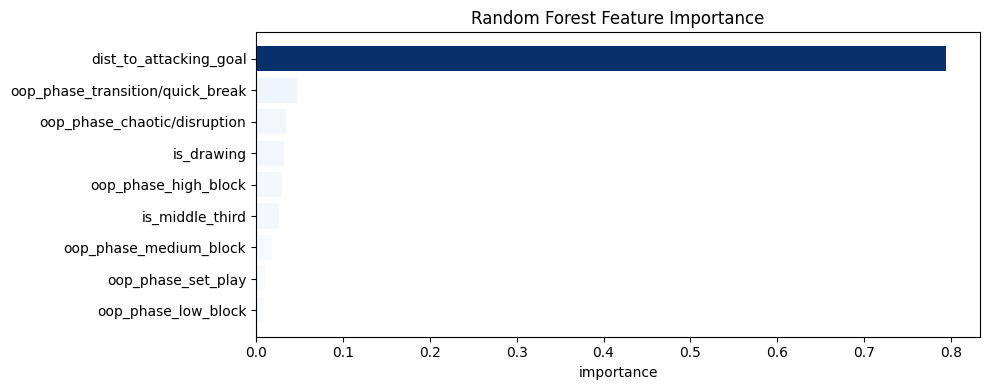

In [75]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(rf_importance, "importance", "Random Forest Feature Importance", cmap="Blues")


C:\Users\navee\AppData\Local\Temp\ipykernel_36332\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


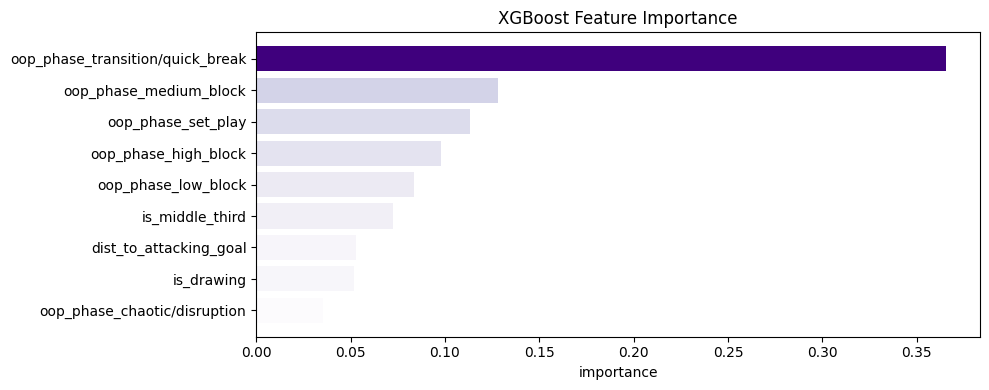

In [76]:
xgb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(xgb_importance, "importance", "XGBoost Feature Importance", cmap="Purples")



C:\Users\navee\AppData\Local\Temp\ipykernel_36332\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


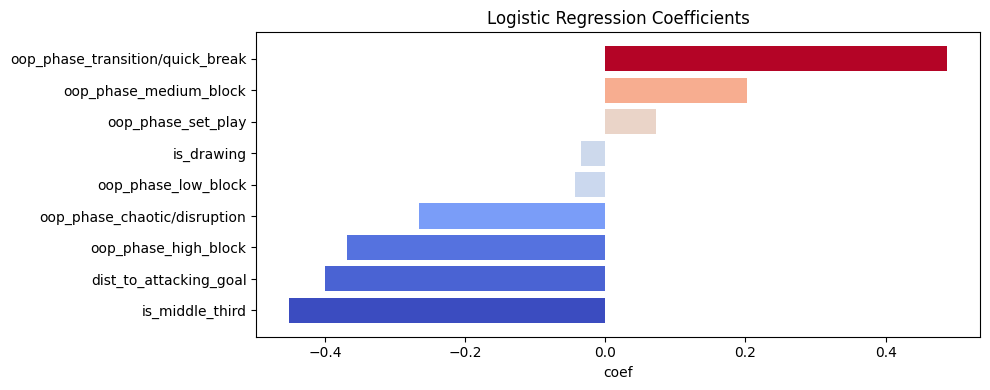

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced"))
])

logreg_pipe.fit(X_train, y_train)

feature_names = X.columns
coefs = logreg_pipe.named_steps["clf"].coef_[0]

logreg_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

plot_gradient_bars(logreg_importance, "coef", "Logistic Regression Coefficients", cmap="coolwarm")




In [78]:
# Get predicted class (0/1)
pred_class = logreg.predict(X_test)

# Get predicted probability of being dangerous
pred_prob = logreg.predict_proba(X_test)[:, 1]

# Build a results dataframe
results = pd.DataFrame({
    "row_index": row_test.values,
    "true_value": y_test.values,
    "predicted_class": pred_class,
    "predicted_probability": pred_prob
})

full_results = results.merge(
    og_df, 
    left_on="row_index", 
    right_on="row_index",
    how="left"
)

full_results

full_results.to_csv('../../Our Datasets/classifier_results_logreg.csv', index=False)
